In [1]:
from utils import *

In [2]:
import pandas as pd
import pickle
path_neuron_df = '/Users/cgty/Library/Mobile Documents/com~apple~CloudDocs/CLASSES/FSU/MyResearch/GITHUB/Persistent-Homology-Pipeline-for-Neural-Spike-Train-Data/Datasets/NeuronDF.pickle' # fill this in yourself
pairs = pd.read_csv('pairs.csv',dtype= {'Date':str}) # pairs is a csv file that helps keep a fixed order for Mouse-Date pairs
with open(path_neuron_df,'rb') as file:
    Df = pickle.load(file)

In [3]:

# helper functions to work with Df
def get_raster(Mouse,Date,Taste,Trial,time_interval = [0,4000]):
    """
    INPUT:
    1) Mouse = str
    2) Date = str
    3) Taste = int
    4) Trial = int
    5) time_interval = list with two entries. It will tell the min and max time to look at in the raster. Set to 0ms - 4000ms by default.
    OUTPUT: numpy array. Will extract from Df the specified raster plot
    """
    frame = Df[(Df['MouseID'] == Mouse) & (Df['Date'] == Date) & (Df['Taste'] == Taste) & (Df['Trial'] == Trial)].iloc[:,7:] # Column 7 and on is spike train
    frame_array = np.array(frame) # turn it into a numpy array. This represents the whole 4000ms
    
    #### Extract the time interval specified ####
    time_begin = time_interval[0]
    time_end = time_interval[1]
    
    frame_array = frame_array[:,time_begin:time_end] # update the frame_array to extract the specified time interval

    return frame_array

def get_dates(Mouse):
    """
    INPUT:
    Mouse = str
    OUTPUT: numpy array consisting of dates the given mouse had trials
    """
     # get dates
    out = Df[(Df['MouseID'] == Mouse) & (Df['Taste'] == 0)]['Date'].unique() # This is taste independent. So, we will pick taste 0 as a representative.
    return out

def get_trial(Mouse, Date, Taste):
    """
    INPUT: 
    Mouse
    Date
    Taste
    OUTPUT:
    Number of trials
    """
    out = Df[(Df['MouseID'] == Mouse) & (Df['Date'] == Date) &(Df['Taste'] == Taste)]['Trial'].unique()
    return(len(out))  


def get_neurons(Mouse, Date):
    """
    Input
    Mouse: str
    Date: str 
    Returns
    Neurons that belong to the Mouse-Date pair 
    """
    row_mask = (Df["MouseID"] == Mouse) & (Df["Date"] == Date)
    neurons = np.unique(np.array(Df[row_mask]["Neuron"]))
    return neurons

def get_trial_from_neuron(neuron,taste,time_interval = [2000,4000]):
    """
    Input
    neuron: int -- neuron id index in Df
    taste: int -- 0, 1 or 2.
    time_interval = [2000,4000] by default
    Returns:
    array -- Returns all trials from the neuron-taste pair. array has shape (# of trials, end_time - begin_time)
    """
    row_mask = (Df["Neuron"] == neuron) & (Df["Taste"] == taste)
    trials = np.array(Df[row_mask].iloc[:,7:])
    begin_time = time_interval[0]
    end_time = time_interval[1]
    array = np.array(trials)[:,begin_time:end_time]

    return array

In [4]:
# Map Mouse-Date-Taste (MDT) to all of its corresponding rasters/trials
MDT_to_trials = {}             
for _, row in pairs.iterrows():
    Mouse = row["Mouse"]
    Date = row["Date"]

    for Taste in (0, 1, 2):
        # Assuming get_trial returns an integer count of trials
        n_trials = get_trial(Mouse=Mouse, Date=Date, Taste=Taste)

        raster_list = []
      

        for j in range(n_trials):
            # Fetch raster: Shape is likely (N_neurons, N_timepoints)
            raster = get_raster(Mouse=Mouse, Date=Date, Taste=Taste, Trial=j, time_interval=[2000, 4000])
            raster_list.append(raster)

        # Store
        MDT_to_trials[(Mouse, Date, Taste)] = raster_list

# TDA Pipeline with Repeated holdout validation

## 3-Class TDA

In [5]:
from sklearn.model_selection import StratifiedShuffleSplit
from tqdm import tqdm
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

def rasters_to_barcode(list_of_rasters, dim = 0):
    list_of_barcodes = []
    for raster in list_of_rasters:
        vp_dm = VP_trivial(raster)
        dgm = ripser(vp_dm,distance_matrix= True)['dgms'][dim]
        list_of_barcodes.append(dgm)

    return list_of_barcodes

def tda_rhv(rasters,labels,dim = 0,n_repeats = 20, test_size = 0.3, random_state = 42): # TDA pipeline with repeated holdout validation (rhv)

    X_barcodes = rasters_to_barcode(X_rasters,dim = dim)
    n = len(X_barcodes)
    BDM = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(i + 1, n):
            if dim == 0:
                d = bottleneck_zero(X_barcodes[i], X_barcodes[j]) 
            else:
                d = persim.bottleneck(X_barcodes[i],X_barcodes[j])
            
            BDM[i, j] = d
            BDM[j, i] = d

    splitter = StratifiedShuffleSplit(
        n_splits=n_repeats, test_size=test_size, random_state=random_state
    )

    scores = []
    for train_idx, test_idx in splitter.split(np.zeros_like(y), y):
        D_train = BDM[np.ix_(train_idx, train_idx)]
        D_test = BDM[np.ix_(test_idx, train_idx)]

        knn = KNeighborsClassifier(n_neighbors=1, metric="precomputed")
        knn.fit(D_train, y[train_idx])
        preds = knn.predict(D_test)

        scores.append(accuracy_score(y[test_idx], preds))

    mean_score = np.mean(scores) 
    return mean_score


In [6]:
# run a for loop to iterate through all Mouse-Date pairs
# as you do so, save the information in a pandas data frame
# first we do 3-class classification
results_list_3class = []
for index, row in tqdm(pairs.iterrows(), total=pairs.shape[0]):
    Mouse = row['Mouse']
    Date = row['Date']

    stim_0_trials = MDT_to_trials[(Mouse, Date, 0)]
    stim_1_trials = MDT_to_trials[(Mouse, Date, 1)]
    stim_2_trials = MDT_to_trials[(Mouse, Date, 2)]

    X_rasters = stim_0_trials + stim_1_trials + stim_2_trials
    y = np.array(
        [0] * len(stim_0_trials) +
        [1] * len(stim_1_trials) +
        [2] * len(stim_2_trials)
    )
    
    score = tda_rhv(X_rasters,y)
    
    if score is not None:
        # Save to our results list
        results_list_3class.append({
            'Mouse': Mouse,
            'Date': Date,
            'TDA Score': score
        })
    
MD_scores_table_3class = pd.DataFrame(results_list_3class)

MD_scores_table_3class.to_csv('tda_scores_rhv_3class.csv', index=False)

100%|██████████| 38/38 [00:07<00:00,  5.08it/s]


In [7]:
MD_scores_table_3class.head()

,Mouse,Date,TDA Score
0,CB279,121621,0.511111
1,CB279,121421,0.476000
2,CB279,122021,0.603704
3,CB278,121521,0.458333
4,CB278,121721,0.477778


## 2-Class TDA (Taste 0 vs 1)

In [8]:
# run a for loop to iterate through all Mouse-Date pairs
# as you do so, save the information in a pandas data frame
# we now do 2-class classification
results_list_2class = []
for index, row in tqdm(pairs.iterrows(), total=pairs.shape[0]):
    Mouse = row['Mouse']
    Date = row['Date']

    stim_0_trials = MDT_to_trials[(Mouse, Date, 0)]
    stim_1_trials = MDT_to_trials[(Mouse, Date, 1)]
    # stim_2_trials = MDT_to_trials[(Mouse, Date, 2)]

    X_rasters = stim_0_trials + stim_1_trials
    y = np.array(
        [0] * len(stim_0_trials) +
        [1] * len(stim_1_trials)
    )
    
    score = tda_rhv(X_rasters,y)
    
    if score is not None:
        # Save to our results list
        results_list_2class.append({
            'Mouse': Mouse,
            'Date': Date,
            'TDA Score': score
        })
    
MD_scores_table_2class = pd.DataFrame(results_list_2class)

MD_scores_table_2class.to_csv('tda_scores_rhv_2class.csv', index=False)

100%|██████████| 38/38 [00:04<00:00,  8.10it/s]


In [9]:
# 2-class TDA scores
MD_scores_table_2class.head()

,Mouse,Date,TDA Score
0,CB279,121621,0.733333
1,CB279,121421,0.668750
2,CB279,122021,0.850000
3,CB278,121521,0.816667
4,CB278,121721,0.830556


# SVM

In [10]:
from scipy.ndimage import gaussian_filter
MDT_to_smoothed_trials = {} # map (Mouse,Date,Taste) to smoothed trials

sigma = 30 # gaussian smoothing parameter

for _, row in pairs.iterrows():
    Mouse = row["Mouse"]
    Date = row["Date"]

    for Taste in (0, 1, 2):
        # Assuming get_trial returns an integer count of trials
        n_trials = get_trial(Mouse=Mouse, Date=Date, Taste=Taste)

        raster_list = []
        raster_vec_list = []
        # We need a list to store the smoothed trials for this specific (M, D, T)
        raster_smooth_list = [] 

        for j in range(n_trials):
            # Fetch raster: Shape is (N_neurons, N_timepoints)
            raster = get_raster(Mouse=Mouse, Date=Date, Taste=Taste, Trial=j, time_interval=[2000, 4000])
            
            # Smooth the raster
            # sigma=(0, sigma) ensures we only smooth along time (axis 1), NOT across neurons (axis 0)
            smoothed_raster = gaussian_filter(raster.astype(float), sigma=(0, sigma))
            
            # Store the flattened version of the smoothed raster
            raster_smooth_list.append(smoothed_raster.flatten())

        # Save the smoothed list to the dictionary
        MDT_to_smoothed_trials[(Mouse, Date, Taste)] = raster_smooth_list

In [11]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

def make_xy_svm(Mouse, Date, tastes=(0, 1, 2)):
    X_list = []
    y_list = []

    for Taste in tastes:
        trials_vec = MDT_to_smoothed_trials.get((Mouse,Date,Taste),[])
        for vec in trials_vec:
            X_list.append(vec)
            y_list.append(Taste)

    if len(X_list) == 0:
        return None, None

    lengths = [len(v) for v in X_list]
    if len(set(lengths)) != 1:
        raise ValueError(
            f"Inconsistent feature lengths for Mouse={Mouse}, Date={Date}. "
            f"Unique lengths={sorted(set(lengths))[:5]}..."
        )

    X = np.vstack(X_list)
    y = np.array(y_list)
    return X, y



def svm_score_rhv(Mouse, Date, tastes=(0, 1, 2), C=1.0,
                  n_repeats=20, test_size=0.3, random_state=42):
    X, y = make_xy_svm(Mouse, Date, tastes=tastes)
    if X is None:
        return np.nan, {}

    classes, counts = np.unique(y, return_counts=True)
    counts_dict = dict(zip(classes, counts))
    if counts.min() < 2:
        return np.nan, counts_dict

    model = make_pipeline(
        StandardScaler(with_mean=True),
        SVC(kernel="linear", C=C),
    )

    splitter = StratifiedShuffleSplit(
        n_splits=n_repeats, test_size=test_size, random_state=random_state
    )

    scores = []
    for train_idx, test_idx in splitter.split(X, y):
        model.fit(X[train_idx], y[train_idx])
        preds = model.predict(X[test_idx])
        scores.append(accuracy_score(y[test_idx], preds))

    return float(np.mean(scores)), counts_dict, float(np.std(scores,ddof = 1))




## SVM 3-Class

In [12]:
# ---- Run for all Mouse-Date pairs and store in a dataframe ----
svm_results_list_3class = []

for _, row in tqdm(pairs.iterrows(), total=pairs.shape[0]):
    Mouse = row["Mouse"]
    Date = row["Date"]

    try:
        score, counts, std = svm_score_rhv(Mouse, Date, tastes=(0, 1, 2), C=1.0)
        svm_results_list_3class.append(
            {"Mouse": Mouse, "Date": Date, "SVM Score": score,'SVM std':std, "Counts": counts}
        )
    except Exception as e:
        svm_results_list_3class.append(
            {"Mouse": Mouse, "Date": Date, "SVM Score": np.nan,'SVM std':np.nan, "Counts": {}, "Error": str(e)}
        )

SVM_scores_table = pd.DataFrame(svm_results_list_3class)

SVM_scores_table.to_csv("SVM_smoothed_rhv_3class.csv", index=False)



100%|██████████| 38/38 [01:53<00:00,  2.99s/it]


In [13]:
# 3-class SVM scores
SVM_scores_table.head()

,Mouse,Date,SVM Score,SVM std,Counts
0,CB279,121621,0.681481,0.073487,"{0: 30, 1: 30, 2: 30}"
1,CB279,121421,0.800000,0.092679,"{0: 23, 1: 29, 2: 30}"
2,CB279,122021,0.583333,0.094522,"{0: 30, 1: 29, 2: 30}"
3,CB278,121521,0.787500,0.088543,"{0: 29, 1: 20, 2: 28}"
4,CB278,121721,0.762963,0.064037,"{0: 29, 1: 30, 2: 29}"


## SVM 2-Class


In [14]:
# ---- Run for all Mouse-Date pairs and store in a dataframe ----
svm_results_list_2class = []

for _, row in tqdm(pairs.iterrows(), total=pairs.shape[0]):
    Mouse = row["Mouse"]
    Date = row["Date"]

    try:
        score, counts, std = svm_score_rhv(Mouse, Date, tastes=(0, 1), C=1.0)
        svm_results_list_2class.append(
            {"Mouse": Mouse, "Date": Date, "SVM Score": score,'SVM std':std, "Counts": counts}
        )
    except Exception as e:
        svm_results_list_2class.append(
            {"Mouse": Mouse, "Date": Date, "SVM Score": np.nan,'SVM std':np.nan, "Counts": {}, "Error": str(e)}
        )

SVM_scores_table_2class = pd.DataFrame(svm_results_list_2class)

SVM_scores_table_2class.to_csv("SVM_smoothed_rhv_2class.csv", index=False)



100%|██████████| 38/38 [00:40<00:00,  1.07s/it]


In [15]:
SVM_scores_table_2class.head()

,Mouse,Date,SVM Score,SVM std,Counts
0,CB279,121621,0.858333,0.052473,"{0: 30, 1: 30}"
1,CB279,121421,0.937500,0.078535,"{0: 23, 1: 29}"
2,CB279,122021,0.788889,0.089399,"{0: 30, 1: 29}"
3,CB278,121521,0.906667,0.095268,"{0: 29, 1: 20}"
4,CB278,121721,0.938889,0.056713,"{0: 29, 1: 30}"


# Single neurons

In [16]:
single_neuron_scores_path = 'Datasets/gctemp_sna_withMDpair_info.csv' # fill this in yourself
single_neuron_scores = pd.read_csv(single_neuron_scores_path,dtype= {"Date":str},keep_default_na= False)

# Map each MD pair to a tuple (x,y) where x is top neuron score and y is the average neuron score
MD_to_ind_neuron_scores = {}
for _, row in pairs.iterrows():
    m = row['Mouse']
    d = row['Date']

    all_neuron_scores = list(single_neuron_scores[(single_neuron_scores['MouseID'] == m) &
                                             (single_neuron_scores['Date'] == d)
                                             ]['SNAscore'])
    MD_to_ind_neuron_scores[(m,d)] = all_neuron_scores


    

In [17]:
# example for MD to ind neuron scores
MD_to_ind_neuron_scores[('CB280','121521')]


[0.6,
 0.8549019607843137,
 0.403921568627451,
 0.6313725490196078,
 0.5568627450980392,
 0.5019607843137255]


# Plots

In [18]:
# prepare data for plotting
from functools import reduce
# prep TDA data
df_TDA_3class = pd.read_csv('tda_scores_rhv_3class.csv')
df_TDA_2class = pd.read_csv('tda_scores_rhv_2class.csv')

# prep SVM data
df_SVM_3class = pd.read_csv('SVM_smoothed_rhv_3class.csv')
df_SVM_2class = pd.read_csv("SVM_smoothed_rhv_2class.csv")


# merge all data into one dataframe

# 1. Format the 'Date' column in all dataframes to have leading zeros
for df in [df_TDA_3class, df_TDA_2class, df_SVM_3class, df_SVM_2class]:
    df['Date'] = df['Date'].astype(str).str.zfill(6)



In [19]:
# Rename columns for the final merged dataframe
tda3 = df_TDA_3class[['Mouse', 'Date', 'TDA Score']].rename(columns={'TDA Score': 'TDA 3-class'})
tda2 = df_TDA_2class[['Mouse', 'Date', 'TDA Score']].rename(columns={'TDA Score': 'TDA 2-class'})
svm3 = df_SVM_3class[['Mouse', 'Date', 'SVM Score']].rename(columns={'SVM Score': 'SVM 3-class'})
svm2 = df_SVM_2class[['Mouse', 'Date', 'SVM Score']].rename(columns={'SVM Score': 'SVM 2-class'})

# 2. Compile the prepared dataframes into a list
dataframes_to_merge = [tda3, tda2, svm3, svm2]

# 3. Merge all dataframes on 'Mouse' and 'Date'
merged_df = reduce(lambda left, right: pd.merge(left, right, on=['Mouse', 'Date'], how='inner'), dataframes_to_merge)


# Create the Experiment label (Mouse-Date)
merged_df['Experiment'] = merged_df['Mouse'] + '-' + merged_df['Date']

# Add columns for individual neuron scores average
def get_avg_ind_score(row):
    key = (row['Mouse'], row['Date'])
    if key in MD_to_ind_neuron_scores:
        return np.mean(MD_to_ind_neuron_scores[key])
    return np.nan

merged_df['Avg Ind Score'] = merged_df.apply(get_avg_ind_score, axis=1)
merged_df.head()

,Mouse,Date,TDA 3-class,TDA 2-class,SVM 3-class,SVM 2-class,Experiment,Avg Ind Score
0,CB279,121621,0.511111,0.733333,0.681481,0.858333,CB279-121621,0.478307
1,CB279,121421,0.476000,0.668750,0.800000,0.937500,CB279-121421,0.410893
2,CB279,122021,0.603704,0.850000,0.583333,0.788889,CB279-122021,0.447222
3,CB278,121521,0.458333,0.816667,0.787500,0.906667,CB278-121521,0.483056
4,CB278,121721,0.477778,0.830556,0.762963,0.938889,CB278-121721,0.457044


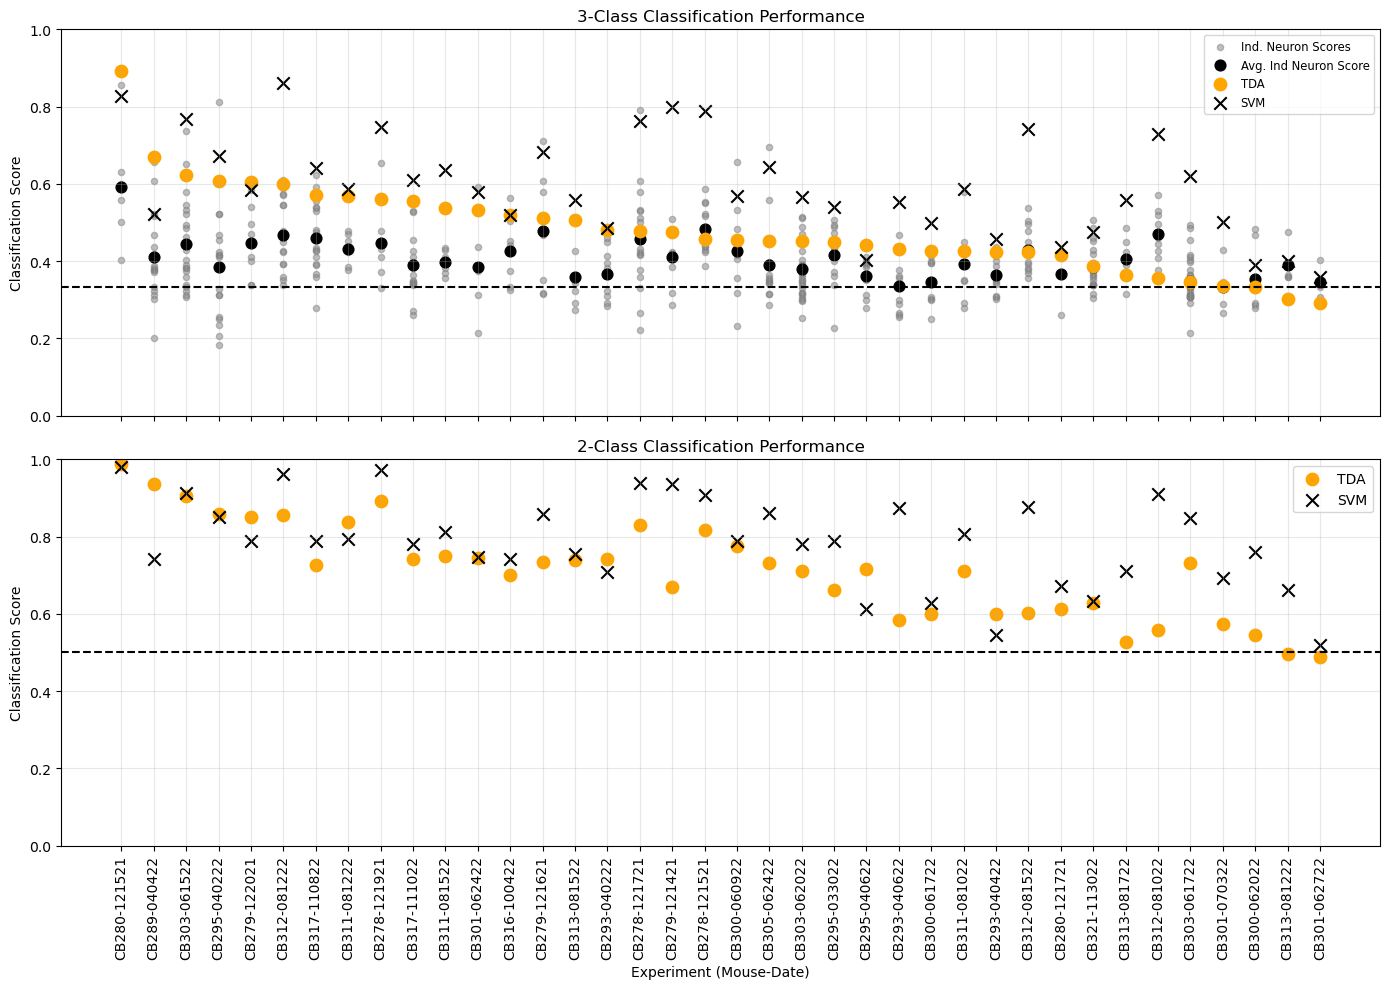

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Sort the dataframe by 'TDA 3-class' descending before plotting
merged_df = merged_df.sort_values(by='TDA 3-class', ascending=False).reset_index(drop=True)

# 2. Set up the figure with two subplots sharing the x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
plt.subplots_adjust(hspace=0.1) # Reduce space between plots

# X-axis data for alignment (now sorted)
experiments = merged_df['Experiment']
x_ticks = np.arange(len(experiments))

# --- Plot 1: 3-class data ---
ax1.set_title('3-Class Classification Performance')
ax1.set_ylabel('Classification Score')
ax1.set_ylim(0, 1)
ax1.grid(axis='both', linestyle='-', alpha=0.3)

# Define reference lines
chance_3class = 1/3
ax1.axhline(y=chance_3class, color='black', linestyle='--')

# Plot Individual Neuron Scores (gray dots) and Average (black dot) for 3-class
for i, exp in enumerate(experiments):
    mouse = merged_df.iloc[i]['Mouse']
    date = merged_df.iloc[i]['Date']
    key = (mouse, date)
    
    if key in MD_to_ind_neuron_scores:
        scores = MD_to_ind_neuron_scores[key]
        x_values = [i] * len(scores) # All scores for this exp align vertically
        
        # Plot individual gray dots (only once per legend entry)
        if i == 0:
            ax1.scatter(x_values, scores, color='gray', alpha=0.5, s=20, label='Ind. Neuron Scores')
        else:
            ax1.scatter(x_values, scores, color='gray', alpha=0.5, s=20)

# Plot Average Ind Neuron Score (black dot, slightly larger)
ax1.scatter(x_ticks, merged_df['Avg Ind Score'], color='black', s=60, label='Avg. Ind Neuron Score')

# Plot TDA 3-class (orange dot)
ax1.scatter(x_ticks, merged_df['TDA 3-class'], color='orange', marker='o', s=80, label='TDA')

# Plot SVM 3-class (black 'x')
ax1.scatter(x_ticks, merged_df['SVM 3-class'], color='black', marker='x', s=80, label='SVM')

ax1.legend(loc='upper right', bbox_to_anchor=(1, 1), fontsize='small')


# --- Plot 2: 2-class data ---
ax2.set_title('2-Class Classification Performance')
ax2.set_ylabel('Classification Score')
ax2.set_xlabel('Experiment (Mouse-Date)')
ax2.set_ylim(0, 1)
ax2.grid(axis='both', linestyle='-', alpha=0.3)

# Define reference lines
chance_2class = 1/2
ax2.axhline(y=chance_2class, color='black', linestyle='--')

# Plot TDA 2-class (orange dot)
ax2.scatter(x_ticks, merged_df['TDA 2-class'], color='orange', marker='o', s=80, label='TDA')

# Plot SVM 2-class (black 'x')
ax2.scatter(x_ticks, merged_df['SVM 2-class'], color='black', marker='x', s=80, label='SVM')

# Formatting x-axis labels (shared across both subplots)
ax2.set_xticks(x_ticks)
ax2.set_xticklabels(experiments, rotation=90) # Rotate for readability
ax2.legend(loc='upper right', bbox_to_anchor=(1, 1))

plt.tight_layout()

# Save the figure as a PDF before displaying
plt.savefig('classification_performance_TDA_SVM.pdf', format='pdf', bbox_inches='tight')

plt.show()